# LAB. De PDI - Leitura, Processamento Básico, Resoluções, Quantização




## Parte I: Manipulação de Imagens Digitais

### Carregar e Exibir Imagem em Tons de Cinza



In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

In [30]:
# Baixa a imagem direto da URL(Sem precisar de upload manual toda vez que o colab reiniciar)
!wget -q -O monalisa.jpg https://upload.wikimedia.org/wikipedia/commons/b/b9/Mona_Lisa.PNG

In [31]:
# Ler a imagem diretamente em escala de cinza
imagem = cv2.imread('monalisa.jpg', cv2.IMREAD_GRAYSCALE)

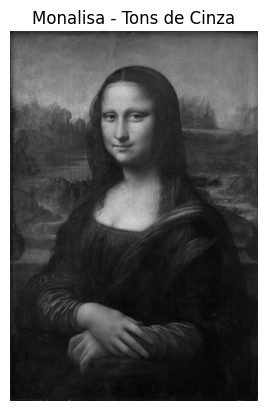

In [32]:
# Tratamento de erro
if imagem is None:
  print("Erro ao carregar a imagem. Verifique o download ou o caminho.")
else:
  # Exibição da imagem
  plt.imshow(imagem, cmap='gray')
  plt.title('Monalisa - Tons de Cinza')
  plt.axis('off')
  plt.show()

In [ ]:
# Exibição da Imagem e Cálculos Dinâmicos
print("\n--- Informações da Imagem ---")
print(f"Shape (Resolução: Altura x Largura): {imagem.shape}")
print(f"Tipo de dado (Data type): {imagem.dtype}")

# Extraindo as dimensões reais da imagem armazenada na variável
altura, largura = imagem.shape

# Como é uma imagem de 8 bits (1 byte por pixel), o tamanho em byte é altura * largura
tamanho_calculado_kb = (altura * largura) / 1024

# Pegando o tamanho real que a matriz numpy está ocupando na memória RAM
tamanho_medido_kb = sys.getsizeof(imagem) / 1024

print(f"Tam. Calculado: {tamanho_calculado_kb:.2f} KB")
print(f"Tam. Medido: {tamanho_medido_kb:.2f} KB")


--- Informações da Imagem ---
Shape (Resolução: Altura x Largura): (3591, 2403)
Tipo de dado (Data type): uint8
Tam. Calculado: 8426.93 KB
Tam. Medido: 8427.05 KB


### **Perguntas de Reflexão:**

* O que significam os valores de intensidade dos pixels em uma imagem em tons de cinza?

  Em uma imagem em tons de cinza, os valores de intensidade dos pixels representam diretamente a quantidade de luz, ou luminância, capturada em cada ponto específico da cena. Nessa escala, o valor numérico zero corresponde à ausência total de luz, resultando no preto absoluto, enquanto o valor máximo representa a intensidade luminosa máxima, ou seja, o branco puro. Todos os valores numéricos intermediários formam as diferentes variações de tons de cinza que compõem os detalhes visuais da imagem, criando os contornos, as texturas e as sombras.

* Por que a imagem é representada em uint8? Como isso afeta a precisão e qualidade?

  A escolha do tipo de dado uint8, que significa um número inteiro sem sinal de 8 bits, ocorre porque essa arquitetura computacional permite armazenar exatamente 256 níveis diferentes de intensidade por pixel, variando de 0 a 255. O uso desse formato é o padrão ideal porque o olho humano possui uma limitação biológica e dificilmente consegue distinguir mais do que esses 256 tons simultaneamente em uma mesma imagem. Dessa forma, o formato uint8 garante uma transição suave de tons e uma percepção visual de excelente qualidade, ao mesmo tempo em que otimiza significativamente o espaço ocupado na memória RAM e no armazenamento do computador.

### Inversão (Negativo) de Imagem

In [33]:
# 1. Criar o negativo da imagem (Operação vetorizada do NumPy)
negativo = 255 - imagem

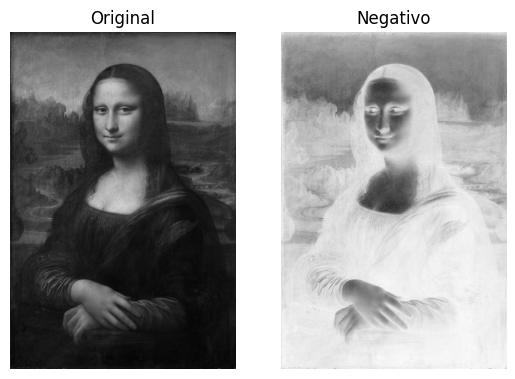

In [34]:
# Configurando exibição lado a lado
# Cria uma figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2)

# Plotando a Original no primeiro quadro (índice 0)
axes[0].imshow(imagem, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Plotando o Negativo no segundo quadro (índice 1)
axes[1].imshow(negativo, cmap='gray')
axes[1].set_title('Negativo')
axes[1].axis('off')

# Exibe a imagem
plt.show()

### **Perguntas de Reflexão:**

* O que acontece com os valores dos pixels quando
criamos o negativo? Como isso altera a percepção
visual?

  Quando aplicamos a operação de inversão para criar o negativo de uma imagem, estamos matematicamente subtraindo o valor original de cada pixel da intensidade máxima permitida na nossa escala, que no caso de uma imagem de 8 bits é 255 (representado pela transformação *s* = 255 - *r* ). Na prática, isso significa que os pixels que originalmente possuíam valores baixos, ou seja, as áreas mais escuras, passam a ter valores altos e se tornam claros. Em contrapartida, as áreas inicialmente claras assumem valores baixos e escurecem, invertendo completamente a escala tonal da imagem. Essa transformação altera drasticamente a nossa percepção visual e é uma técnica muito útil para destacar detalhes anatômicos. O olho humano costuma ter dificuldade para identificar pequenas estruturas claras que estão perdidas em meio a fundos predominantemente escuros. Na área médica, como no exemplo das mamografias, criar o negativo da imagem faz com que lesões que estavam ofuscadas na imagem original se destaquem de forma muito mais nítida, facilitando a análise visual.

## Parte II: Quantização de Imagens

### Quantização com Diferentes Bits

In [37]:
# Função matemática para quantização
def quantizar_imagem(img, bits):
  # Calcula o tamanho do "degrau" com base nos bits
  fator = 2 ** (8 - bits)
  # Divide (para agrupar os tons) e multiplica (para restaurar a escala de 0-255)
  img_quantizada = (img // fator) * fator
  return img_quantizada.astype('uint8')

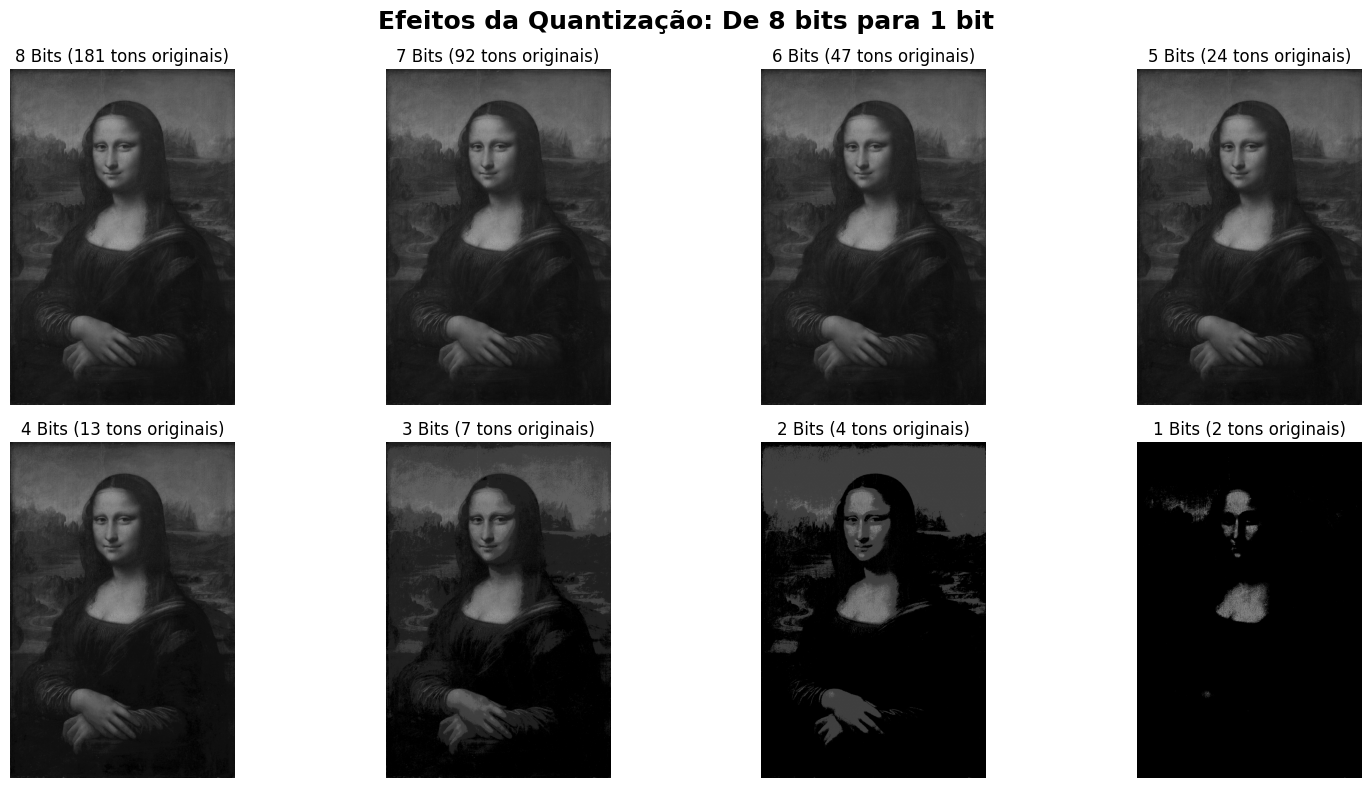

In [40]:
# Configurar um grid de 2 linhas e 4 colunas
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Efeitos da Quantização: De 8 bits para 1 bit', fontsize=18, fontweight='bold')

# Lista de bits que o roteiro pediu para testar
niveis_bits = [8, 7, 6, 5, 4, 3, 2, 1]

# Laço de repetição para gerar e plotar as imagens de uma vez
for i, bits in enumerate(niveis_bits):
  # Calcula matematicamente em qual linha e coluna a imagem deve entrar
  linha = i // 4
  coluna = i % 4
  ax = axes[linha, coluna]

  # Aplica a função de quantização
  img_q = quantizar_imagem(imagem, bits)

  # Conta quantos tons de cinza realmente sobraram na matriz
  cores_unicas = len(np.unique(img_q))

  # Exibe a imagem travando a escala real de luz
  ax.imshow(img_q, cmap='gray', vmin=0, vmax=255)
  ax.set_title(f'{bits} Bits ({cores_unicas} tons originais)')
  ax.axis('off')

plt.tight_layout()
plt.show()


## **Perguntas de Reflexão:**

* Como a redução dos níveis de quantização impacta a qualidade visual?

  A redução dos níveis de quantização afeta diretamente a suavidade das transições de luz e sombra na imagem. O processo de quantização pode ser definido matematicamente pela fórmula $Q(r) = \left\lfloor \frac{r}{k} \right\rfloor \times k$ , onde diminuímos a quantidade de bits por pixel e, consequentemente, reduzimos o número total de tons de cinza disponíveis para representar a cena. O principal impacto visual dessa restrição matemática é o surgimento de um defeito conhecido como falso contorno. Em áreas da imagem que originalmente possuíam um gradiente suave, como o fundo de uma foto ou as sombras de um rosto, a falta de tons intermediários força a criação de blocos de cor sólida com bordas muito marcadas e artificiais, quebrando a ilusão de continuidade visual.

* Qual é o nível mínimo de bits em que a imagem ainda  ́é reconhecível sem muita perda de detalhes?

  Observando os resultados gerados e traçando um paralelo com a referência (Gonzalez), o nível mínimo de bits para que a imagem permaneça amplamente reconhecível e com uma qualidade visual aceitável costuma ficar em torno de cinco ou seis bits por pixel, o que equivale a 32 e 64 tons de cinza, respectivamente. Nesses níveis, um observador atento já começa a perceber sutis falsos contornos nas áreas de transição mais suave, mas as texturas e as estruturas anatômicas principais da imagem ainda estão perfeitamente preservadas. Quando descemos para quatro bits ou menos, a perda de informação tonal se torna muito severa, fazendo com que a imagem adquira um aspecto chapado e artificial de baixíssima resolução, prejudicando drasticamente a identificação de detalhes finos e o reconhecimento imediato de feições complexas.